<a href="https://colab.research.google.com/github/Adyypower/Deep-learning-Models-or-topics/blob/main/localization__model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
try:
  %tensorflow_version 2.x
except Exception:
  pass

import tensorflow as tf
print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.19.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam,SGD

In [4]:
vgg = tf.keras.applications.VGG16(
    input_shape = [100,100,3],include_top = False,weights = 'imagenet'
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
x = Flatten()(vgg.output)
x = Dense(4,activation = 'sigmoid')(x)
model = Model(vgg.input,x)

In [6]:
def image_generator(batch_size = 64):
  while True:
    for _ in range(batch_size):
      x = np.zeros((batch_size,100,100,3))
      y = np.zeros((batch_size,4))

      for i in range(batch_size):
        row0 = np.random.randint(0,90)
        col0 = np.random.randint(0,90)
        row1 = np.random.randint(row0,100)
        col1 = np.random.randint(col0,100)
        x[i,row0:row1,col0:col1,:] = 1
        y[i,0] = row0/100.
        y[i,1] = col0/100.
        y[i,2] = (row1 - row0)/100.
        y[i,3] = (col1 - col0)/100
      yield x,y

In [7]:
model.compile(loss = 'binary_crossentropy',optimizer = Adam(learning_rate = 0.001))

In [8]:
model.fit(image_generator(),steps_per_epoch = 50,epochs = 5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - loss: 0.8629
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - loss: 0.5184
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - loss: 0.5096
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 212ms/step - loss: 0.5055
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - loss: 0.5076


In [9]:
from matplotlib.patches import Rectangle
def make_prediction():
  x = np.zeros((100,100,3))
  row0 = np.random.randint(90)
  col0 = np.random.randint(90)
  row1 = np.random.randint(row0,100)
  col1 = np.random.randint(col0,100)
  x[row0:row1,col0:col1,:] = 1

  # predict
  x_expend = np.expand_dims(x,0)
  p = model.predict(x_expend)[0]

  # Draw the box

  fig,ax = plt.subplots(1)
  ax.imshow(x)
  rect = Rectangle(
      (p[1]*100,p[0]*100),
       p[3]*100 , p[2]*100,linewidth = 1,edgecolor = 'r',facecolor = 'none')

  ax.add_patch(rect)
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


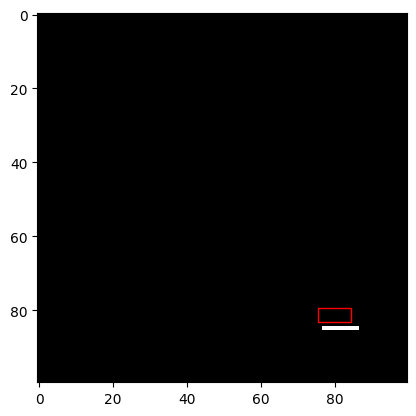

In [10]:
make_prediction()

In [16]:
from tensorflow.keras.preprocessing import image

In [23]:
!wget -nc https://lazyprogrammer.me/course_files/charmander-tight.png

--2025-08-26 04:48:37--  https://lazyprogrammer.me/course_files/charmander-tight.png
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2025-08-26 04:48:37 ERROR 403: Forbidden.



In [24]:
!ls

charmander-tight.png  sample_data


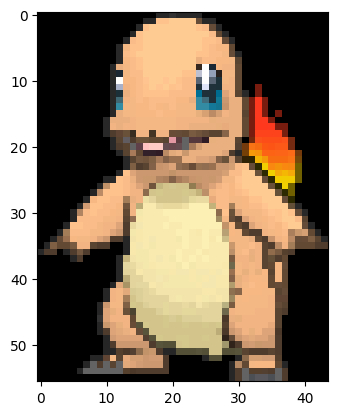

In [25]:
ch = image.load_img('charmander-tight.png')

plt.imshow(ch)
plt.show()

In [26]:
np.array(ch).shape

(56, 44, 3)

In [27]:
from imageio import imread

/tmp/ipython-input-599271760.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  ch = imread('charmander-tight.png')


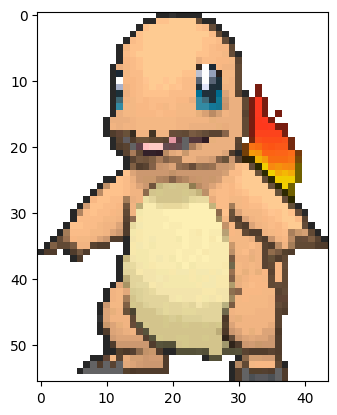

In [28]:
ch = imread('charmander-tight.png')
plt.imshow(ch)

In [29]:
type(ch)

numpy.ndarray

In [30]:
ch.shape

(56, 44, 4)

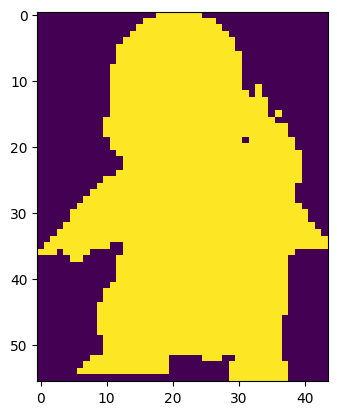

In [32]:
# what is in the 4th channel ?

plt.imshow(ch[:,:,3])
plt.show()

In [33]:
poke_dim = 200
ch = np.array(ch)
ch_h,ch_w,_= ch.shape
def pokemon_generator(batch_size = 64):

  # generate image and labels
  while True:
     for _ in range(batch_size):
      x = np.zeros((batch_size,poke_dim,poke_dim,3))
      y = np.zeros((batch_size,4))
      for i in range(batch_size):
        row0 = np.random.randint( poke_dim - ch_h)
        col0 = np.random.randint( poke_dim - ch_w)
        row1 = row0 + ch_h
        col1 = col0 +ch_w
        # Use the alpha channel to create a 3-channel mask
        mask = np.stack([ch[:,:,3]]*3, axis=-1) > 0
        # Apply the mask to the RGB channels and place it on the background
        x[i,row0:row1,col0:col1,:] = ch[:,:,:3] * mask

        y[i,0] = row0/poke_dim
        y[i,1] = col0/poke_dim

        #later: make the pokemon diffrent sizes

        y[i,2] = (row1 - row0)/poke_dim
        y[i,3] = (col1 - col0)/poke_dim
      yield x/255.,y

In [34]:
def make_model():
  vgg = tf.keras.applications.VGG16(
    input_shape = [poke_dim,poke_dim,3],include_top = False,weights = 'imagenet')
  x = Flatten()(vgg.output)
  x = Dense(4,activation = 'sigmoid')(x)
  model = Model(vgg.input,x)
  model.compile(loss = 'binary_crossentropy',optimizer = Adam(learning_rate = 0.001))
  return model

In [35]:
model = make_model()
model.fit(
    pokemon_generator(),steps_per_epoch = 50,epochs = 5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 96s 732ms/step - loss: 1.1779
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 732ms/step - loss: 0.5588
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 731ms/step - loss: 0.5558
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 732ms/step - loss: 0.5542
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 731ms/step - loss: 0.5537


In [36]:
# Make prediction

def pokemon_prediction():
  x = np.zeros((poke_dim,poke_dim,3))
  row0 = np.random.randint(poke_dim - ch_h)
  col0 = np.random.randint(poke_dim - ch_w)
  row1 = row0 + ch_h
  col1 = col0 + ch_w
  # Use the alpha channel to create a 3-channel mask
  mask = np.stack([ch[:,:,3]]*3, axis=-1) > 0
  # Apply the mask to the RGB channels and place it on the background
  x[row0:row1,col0:col1,:] = ch[:,:,:3] * mask
  print('true:',row0,col0,row1,col1)

  #predict

  x_expanded = np.expand_dims(x,0)/255.
  p = model.predict(x_expanded)[0]


  #calculate target /loss

  y = np.zeros(4)
  y[0] = row0/poke_dim
  y[1] = col0/poke_dim
  y[2] = (row1 - row0)/poke_dim
  y[3] = (col1 - col0)/poke_dim

  #draw the box

  row0 = int(p[0]*poke_dim)
  col0 = int(p[1]*poke_dim)
  row1 = int(row0 +p[2]*poke_dim)
  col1 = int(col0 +p[3]*poke_dim)
  print('pred:',row0,col0,row1,col1)
  print('loss:', -np.mean(y*np.log(p) + (1-y)*np.log(1-p)))

  fig,ax = plt.subplots(1)
  ax.imshow(x.astype(np.uint8))
  rect = Rectangle(
      (p[1]*poke_dim,p[0]*poke_dim),
      p[3]*poke_dim,p[ 2]*poke_dim,linewidth = 1,edgecolor = 'r',facecolor = 'none')
  ax.add_patch(rect)
  plt.show()

true: 142 35 198 79
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
pred: 144 32 199 76
loss: 0.5466249186545611


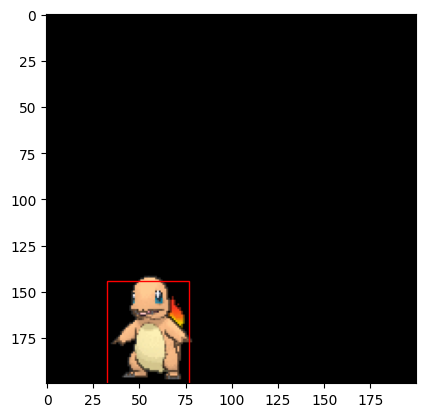

In [37]:
pokemon_prediction()